# Week 4 Tutorial — Gradient Descent from Scratch

**How to use this notebook:**
Read one section of `study-guide.md`, then do that section here before moving on.

Each section has:
- A worked example (pre-written — just run it)
- A **DO IT YOURSELF** cell with different data

At the end: one capstone that chains everything together.

---

In [15]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)
print('Setup complete.')

Setup complete.


---
## §1 — What Is a Derivative?

Read `study-guide.md §1` first, then work through this section.

In [16]:
# EXAMPLE: f(x) = x²  →  derivative f'(x) = 2x
# The derivative at any point x tells you the slope at that point.

def f(x):
    return x ** 2

def f_prime(x):       # derivative of x² is 2x
    return 2 * x

# Check slope at a few points
for x in [-3, -1, 0, 2, 4]:
    print(f'x = {x:>3}  →  f(x) = {f(x):>3}  |  slope = {f_prime(x):>3}  ({"uphill" if f_prime(x) > 0 else "downhill" if f_prime(x) < 0 else "flat"})')

x =  -3  →  f(x) =   9  |  slope =  -6  (downhill)
x =  -1  →  f(x) =   1  |  slope =  -2  (downhill)
x =   0  →  f(x) =   0  |  slope =   0  (flat)
x =   2  →  f(x) =   4  |  slope =   4  (uphill)
x =   4  →  f(x) =  16  |  slope =   8  (uphill)


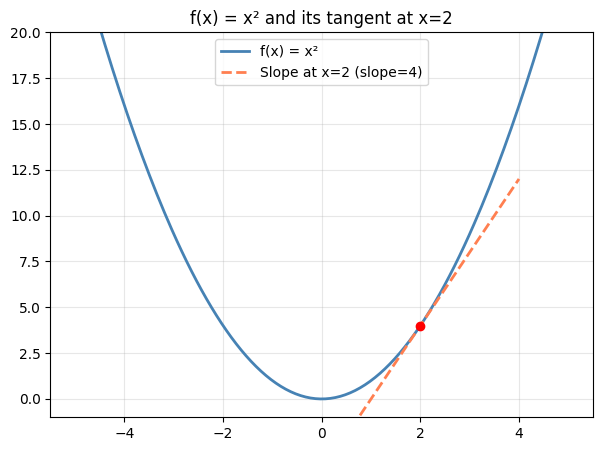

The red dot is where we are. The dashed line is the slope there.
Slope = 4 means: moving right increases f(x) by 4 per unit.
To go downhill, we should move LEFT (opposite of the slope).


In [17]:
# EXAMPLE: visualize f(x) = x² and its slope at x = 2

x_vals = np.linspace(-5, 5, 200)
y_vals = f(x_vals)

# tangent line at x=2: y = f(2) + f'(2) * (x - 2)
x_tan = np.linspace(0, 4, 100)
y_tan = f(2) + f_prime(2) * (x_tan - 2)

plt.figure(figsize=(7, 5))
plt.plot(x_vals, y_vals, 'steelblue', lw=2, label='f(x) = x²')
plt.plot(x_tan, y_tan, 'coral', lw=2, linestyle='--', label='Slope at x=2 (slope=4)')
plt.scatter([2], [f(2)], color='red', zorder=5)
plt.ylim(-1, 20)
plt.legend()
plt.title('f(x) = x² and its tangent at x=2')
plt.grid(alpha=0.3)
plt.show()

print('The red dot is where we are. The dashed line is the slope there.')
print('Slope = 4 means: moving right increases f(x) by 4 per unit.')
print('To go downhill, we should move LEFT (opposite of the slope).')

x =  -2  →  g(x) =   0  |  slope =  10  (uphill)
x =   0  →  g(x) =   0  |  slope =  -2  (downhill)
x =   1  →  g(x) =  -3  |  slope =   1  (uphill)
x =   3  →  g(x) =  15  |  slope =  25  (uphill)


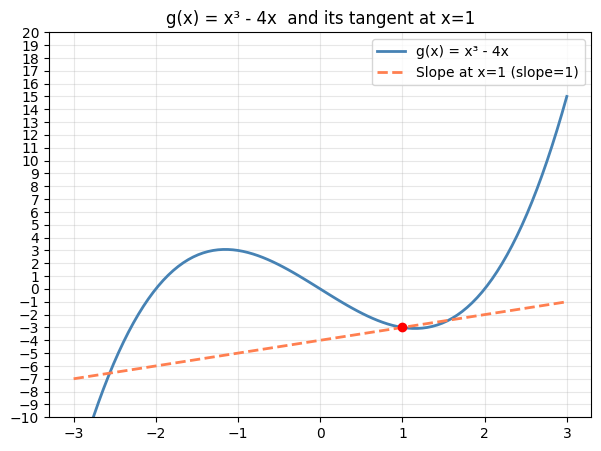

In [ ]:
# DO IT YOURSELF §1
# Function: g(x) = x³ - 4x   →   derivative g'(x) = 3x² - 4
#
# 1. Define g(x) and g_prime(x)
# 2. Print the slope at x = -2, 0, 1, 3
# 3. At which of those points is the function going downhill? (slope < 0)
# 4. Plot g(x) from x=-3 to x=3, and mark the tangent line at x=1

# YOUR CODE HERE
def g(x):
    return (x ** 3) - (4 * x)

def g_prime(x):
    return (3 * (x ** 2)) - 4

for x in [-2, 0, 1, 3]:
    print(f'x = {x:>3}  →  g(x) = {g(x):>3}  |  slope = {g_prime(x):>3}  ({"uphill" if g_prime(x) > 0 else "downhill" if g_prime(x) < 0 else "flat"})')

x_vals = np.linspace(-3, 3, 100)
y_vals = g(x_vals)

x_tan = np.linspace(-3, 3, 100)
y_tan = g(1) + g_prime(1) * (x_tan - 1)

plt.figure(figsize=(7, 5))
plt.plot(x_vals, y_vals, 'steelblue', lw=2, label='g(x) = x³ - 4x')
plt.plot(x_tan, y_tan, 'coral', lw=2, linestyle='--', label='Slope at x=1 (slope=1)')
plt.scatter([1], [g(1)], color='red', zorder=3)
plt.ylim(-10, 20)
plt.yticks(np.arange(-10, 21, 1))
plt.legend()
plt.title('g(x) = x³ - 4x  and its tangent at x=1')
plt.grid(alpha=0.3)
plt.show()



---
## §2 — Loss Functions

Read `study-guide.md §2` first, then work through this section.

In [19]:
# EXAMPLE: compute MSE by hand, then visualize the loss surface

# Simple dataset: house size vs price
X = np.array([1.0, 2.0, 3.0, 4.0, 5.0])   # size (100s of sqft)
y = np.array([2.1, 3.9, 6.2, 7.8, 10.1])  # price (100k)

def mse(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

# Try a few different weights (slopes) and see the loss
print('w     loss (MSE)')
print('-' * 20)
for w in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    y_pred = w * X          # simple model: y = w*x (no bias for now)
    loss = mse(y_pred, y)
    print(f'{w:.1f}   {loss:.3f}')

w     loss (MSE)
--------------------
0.5   24.892
1.0   11.102
1.5   2.812
2.0   0.022
2.5   2.732
3.0   10.942


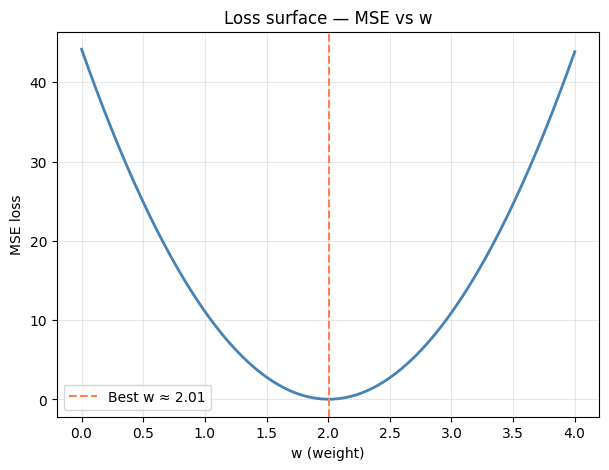

The bowl shape means there is one clear minimum.
Gradient descent will roll to the bottom of this bowl.


In [20]:
# EXAMPLE: plot the loss surface — loss vs w

w_vals = np.linspace(0, 4, 200)
loss_vals = [mse(w * X, y) for w in w_vals]

# Find the best w
best_w = w_vals[np.argmin(loss_vals)]

plt.figure(figsize=(7, 5))
plt.plot(w_vals, loss_vals, 'steelblue', lw=2)
plt.axvline(best_w, color='coral', linestyle='--', label=f'Best w ≈ {best_w:.2f}')
plt.xlabel('w (weight)')
plt.ylabel('MSE loss')
plt.title('Loss surface — MSE vs w')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'The bowl shape means there is one clear minimum.')
print(f'Gradient descent will roll to the bottom of this bowl.')

4.0   2935.667
5.0   2557.833
6.0   2210.333
7.0   1893.167
8.0   1606.333
9.0   1349.833
10.0   1123.667
11.0   927.833
12.0   762.333


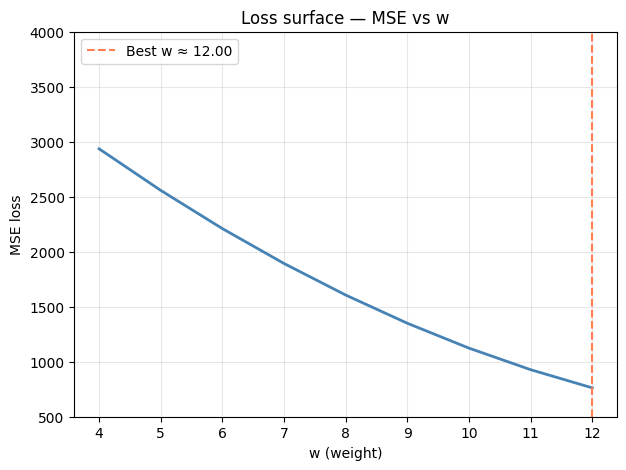

In [29]:
# DO IT YOURSELF §2
# Dataset: study hours vs exam score
X2 = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0])
y2 = np.array([52.0, 58.0, 65.0, 70.0, 78.0, 85.0])
#
# 1. Try w values from 4 to 12 in steps of 1. Print w and MSE for each.
# 2. Which w gives the lowest loss?
# 3. Plot the loss surface (MSE vs w) for w from 1 to 15
# 4. Mark the best w on the plot
# YOUR CODE HERE
w_vals = np.linspace(4, 12, 9)
for w in w_vals:
    y_pred = w * X2
    loss = mse(y_pred, y2)
    print(f'{w:.1f}   {loss:.3f}')

loss_vals = [mse(w * X2, y2) for w in w_vals]
best_w = w_vals[np.argmin(loss_vals)]

plt.figure(figsize=(7, 5))
plt.plot(w_vals, loss_vals, 'steelblue', lw=2)
plt.ylim(500, 4000)
plt.axvline(best_w, color='coral', linestyle='--', label=f'Best w ≈ {best_w:.2f}')
plt.xlabel('w (weight)')
plt.ylabel('MSE loss')
plt.title('Loss surface — MSE vs w')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## §3 — Gradient Descent

Read `study-guide.md §3` first, then work through this section.

In [32]:
# EXAMPLE: gradient descent on f(x) = x² starting at x=4
# This is the simplest possible case — one parameter, one dimension.

def f(x):       return x ** 2
def grad_f(x):  return 2 * x    # derivative of x²

x = 4.0          # starting point
lr = 0.2         # learning rate
history = [x]

for step in range(10):
    grad = grad_f(x)
    x = x - lr * grad       # move opposite to gradient (downhill)
    history.append(x)
    print(f'Step {step+1:>2}: x = {x:>7.4f}  f(x) = {f(x):>8.4f}  grad = {grad:>7.4f}')

print(f'\nConverged near x = {x:.6f} (true minimum is x = 0)')

Step  1: x =  2.4000  f(x) =   5.7600  grad =  8.0000
Step  2: x =  1.4400  f(x) =   2.0736  grad =  4.8000
Step  3: x =  0.8640  f(x) =   0.7465  grad =  2.8800
Step  4: x =  0.5184  f(x) =   0.2687  grad =  1.7280
Step  5: x =  0.3110  f(x) =   0.0967  grad =  1.0368
Step  6: x =  0.1866  f(x) =   0.0348  grad =  0.6221
Step  7: x =  0.1120  f(x) =   0.0125  grad =  0.3732
Step  8: x =  0.0672  f(x) =   0.0045  grad =  0.2239
Step  9: x =  0.0403  f(x) =   0.0016  grad =  0.1344
Step 10: x =  0.0242  f(x) =   0.0006  grad =  0.0806

Converged near x = 0.024186 (true minimum is x = 0)
[4.0, 2.4, 1.44, 0.864, 0.5184, 0.31104, 0.18662399999999998, 0.11197439999999999, 0.06718463999999999, 0.04031078399999999, 0.024186470399999993]


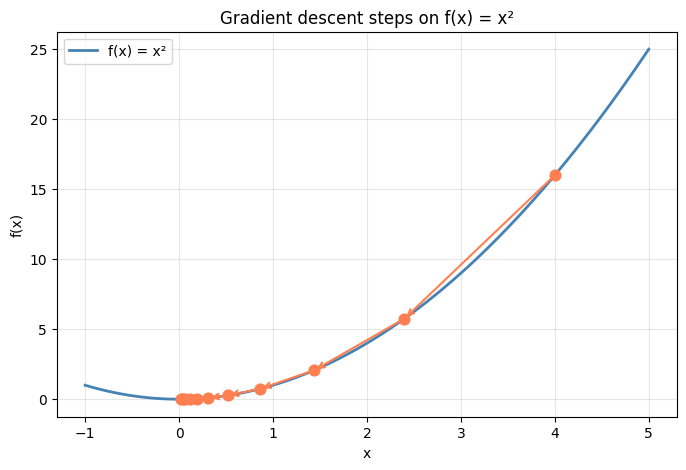

Each arrow is one gradient descent step.
Steps get smaller as slope decreases near the minimum.


In [31]:
# EXAMPLE: visualize the steps taken by gradient descent

x_vals = np.linspace(-1, 5, 200)
plt.figure(figsize=(8, 5))
plt.plot(x_vals, x_vals**2, 'steelblue', lw=2, label='f(x) = x²')

for i, xh in enumerate(history):
    plt.scatter(xh, xh**2, color='coral', zorder=5, s=60)
    if i < len(history) - 1:
        plt.annotate('', xy=(history[i+1], history[i+1]**2),
                     xytext=(xh, xh**2),
                     arrowprops=dict(arrowstyle='->', color='coral', lw=1.5))

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gradient descent steps on f(x) = x²')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print('Each arrow is one gradient descent step.')
print('Steps get smaller as slope decreases near the minimum.')

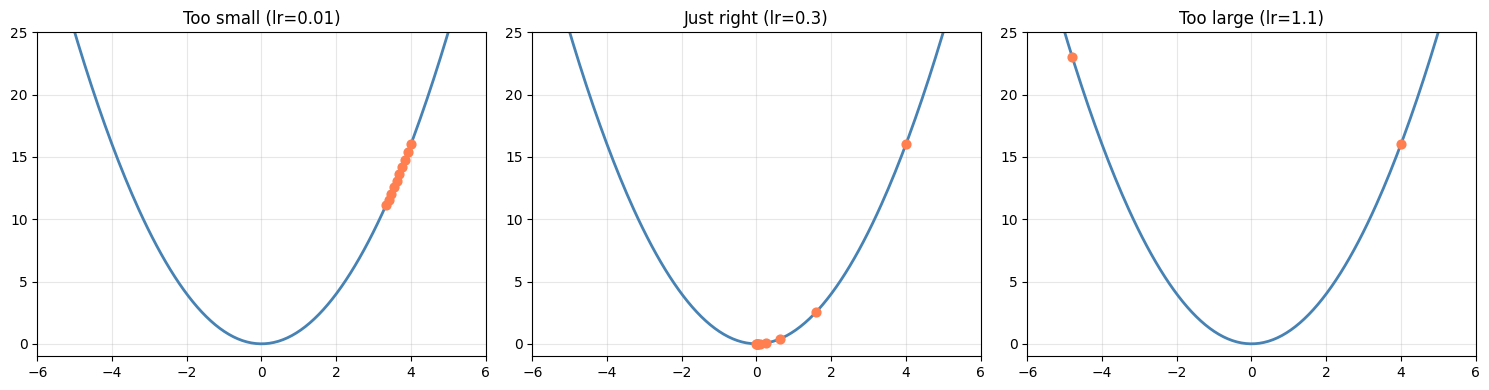

In [33]:
# EXAMPLE: what happens with different learning rates

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_vals = np.linspace(-6, 6, 200)

for ax, (lr, label) in zip(axes, [(0.01, 'Too small (lr=0.01)'),
                                    (0.3,  'Just right (lr=0.3)'),
                                    (1.1,  'Too large (lr=1.1)')]):
    x = 4.0
    hist = [x]
    for _ in range(15):
        x = x - lr * 2 * x
        hist.append(x)
        if abs(x) > 100:   # diverging
            break

    ax.plot(x_vals, x_vals**2, 'steelblue', lw=2)
    for i in range(min(len(hist)-1, 10)):
        ax.scatter(hist[i], hist[i]**2, color='coral', zorder=5, s=40)
    ax.set_title(label)
    ax.set_ylim(-1, 25)
    ax.set_xlim(-6, 6)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Step  1: x = -1.2000  h(x) =  17.6400  grad = -8.0000
Step  2: x = -0.5600  h(x) =  12.6736  grad = -6.4000
Step  3: x = -0.0480  h(x) =   9.2903  grad = -5.1200
Step  4: x =  0.3616  h(x) =   6.9612  grad = -4.0960
Step  5: x =  0.6893  h(x) =   5.3394  grad = -3.2768
Step  6: x =  0.9514  h(x) =   4.1967  grad = -2.6214
Step  7: x =  1.1611  h(x) =   3.3814  grad = -2.0972
Step  8: x =  1.3289  h(x) =   2.7925  grad = -1.6777
Step  9: x =  1.4631  h(x) =   2.3620  grad = -1.3422
Step 10: x =  1.5705  h(x) =   2.0435  grad = -1.0737
Step 11: x =  1.6564  h(x) =   1.8053  grad = -0.8590
Step 12: x =  1.7251  h(x) =   1.6253  grad = -0.6872
Step 13: x =  1.7801  h(x) =   1.4882  grad = -0.5498
Step 14: x =  1.8241  h(x) =   1.3828  grad = -0.4398
Step 15: x =  1.8593  h(x) =   1.3013  grad = -0.3518
Step 16: x =  1.8874  h(x) =   1.2379  grad = -0.2815
Step 17: x =  1.9099  h(x) =   1.1883  grad = -0.2252
Step 18: x =  1.9279  h(x) =   1.1493  grad = -0.1801
Step 19: x =  1.9424  h(x) =

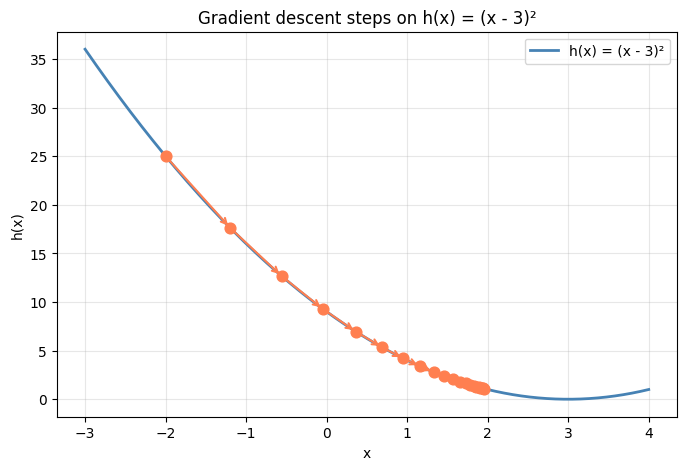

In [94]:
# DO IT YOURSELF §3
# Function: h(x) = (x - 3)²   →   gradient: h'(x) = 2(x - 3)
# (minimum is at x=3, not x=0 — tests that you understand the update rule)
#
# 1. Run gradient descent starting at x = -2, learning rate = 0.1, for 20 steps
# 2. Print x and h(x) at each step
# 3. Plot the function and the steps taken
# 4. Try lr=0.9 — what happens? Add a comment explaining why.

# YOUR CODE HERE
def h(x):
    return (x - 3) ** 2

def grad_h(x):
    return 2 * (x - 2)

x = -2
lr = 0.1
history = [x]

for step in range(20):
    grad = grad_h(x)
    x = x - (lr * grad)
    history.append(x)
    print(f'Step {step+1:>2}: x = {x:>7.4f}  h(x) = {h(x):>8.4f}  grad = {grad:>7.4f}')

x_vals = np.linspace(-3, 4, 200)
y_vals = [h(x) for x in x_vals]
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, 'steelblue', lw=2, label='h(x) = (x - 3)²')

for i, xh in enumerate(history):
    plt.scatter(xh, h(xh), color='coral', zorder=5, s=60)
    if i < len(history) - 1:
        plt.annotate('', xy=(history[i+1], h(history[i+1])),
                     xytext=(xh, h(xh)),
                     arrowprops=dict(arrowstyle='->', color='coral', lw=1.5))

plt.xlabel('x')
plt.ylabel('h(x)')
plt.title('Gradient descent steps on h(x) = (x - 3)²')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#when lr is 0.09, x somehow become zig-zag. not sure why this happens but as steps goes no it still achieves
# getting the flat

---
## §4 — Linear Regression from Scratch

Read `study-guide.md §4` first, then work through this section.

In [49]:
# EXAMPLE: train linear regression on house size vs price using gradient descent

X_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_train = np.array([2.1, 3.9, 6.2, 7.8, 10.1])

# Initialize parameters
w = 0.0
b = 0.0
lr = 0.01
n = len(X_train)

loss_history = []

for epoch in range(200):
    # Forward pass
    y_pred = w * X_train + b

    # Loss
    loss = np.mean((y_pred - y_train) ** 2)
    loss_history.append(loss)

    # Gradients
    dw = (2/n) * np.sum((y_pred - y_train) * X_train)
    db = (2/n) * np.sum((y_pred - y_train))

    # Update
    w = w - lr * dw
    b = b - lr * db

    if epoch % 40 == 0:
        print(f'Epoch {epoch:>3}: loss={loss:.4f}  w={w:.4f}  b={b:.4f}')

print(f'\nFinal: w={w:.4f}  b={b:.4f}')
print(f'Prediction for size=6: {w*6+b:.2f} (100k)')

Epoch   0: loss=44.1820  w=0.4408  b=0.1204
Epoch  40: loss=0.0515  w=1.8778  b=0.4551
Epoch  80: loss=0.0443  w=1.8920  b=0.4038
Epoch 120: loss=0.0389  w=1.9044  b=0.3590
Epoch 160: loss=0.0347  w=1.9153  b=0.3198

Final: w=1.9245  b=0.2865
Prediction for size=6: 11.83 (100k)


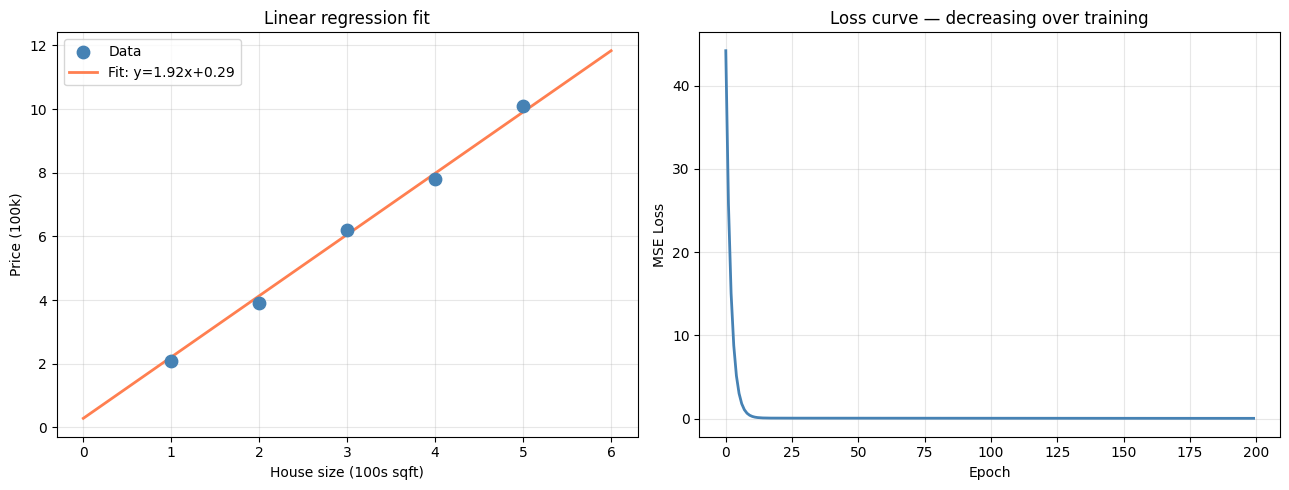

In [50]:
# EXAMPLE: visualize the fitted line and the loss curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Fitted line
x_line = np.linspace(0, 6, 100)
axes[0].scatter(X_train, y_train, color='steelblue', s=80, zorder=5, label='Data')
axes[0].plot(x_line, w * x_line + b, 'coral', lw=2, label=f'Fit: y={w:.2f}x+{b:.2f}')
axes[0].set_xlabel('House size (100s sqft)')
axes[0].set_ylabel('Price (100k)')
axes[0].set_title('Linear regression fit')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(loss_history, 'steelblue', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss curve — decreasing over training')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Epoch 100: loss=116.1290  w=8.8005  b=15.7700
Epoch 200: loss=41.2512  w=7.5864  b=24.2070
Epoch 300: loss=14.8530  w=6.8656  b=29.2165

Final: w=6.8656  b=29.2165
Prediction for size=6: 70.41 (100k)


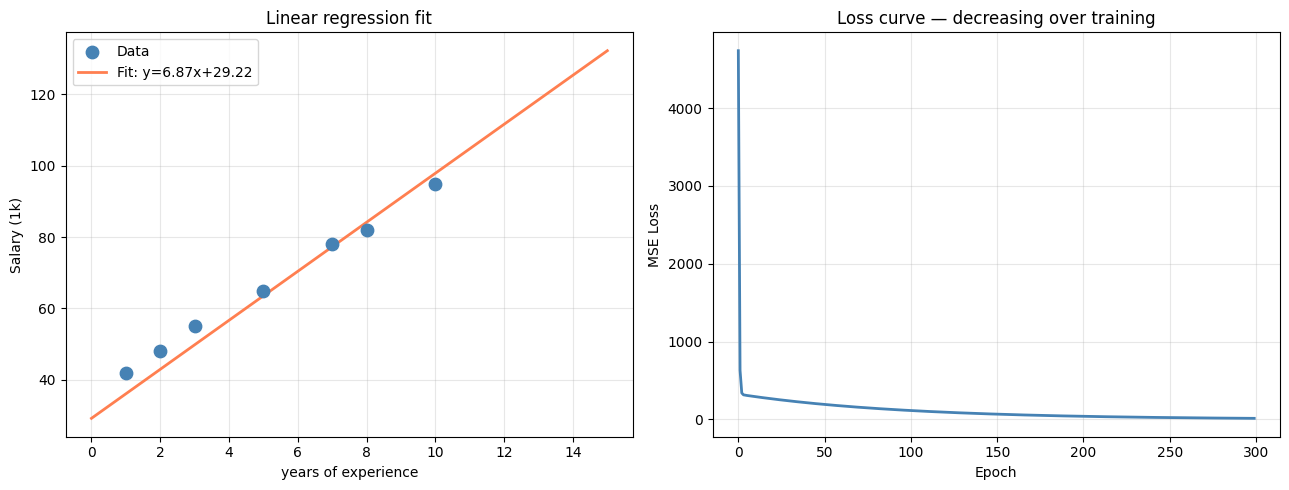

In [67]:
# DO IT YOURSELF §4
# Dataset: years of experience vs salary
X2 = np.array([1.0, 2.0, 3.0, 5.0, 7.0, 8.0, 10.0])
y2 = np.array([42.0, 48.0, 55.0, 65.0, 78.0, 82.0, 95.0])  # salary in $k
#
# 1. Initialize w=0, b=0, lr=0.005, train for 300 epochs
# 2. Print loss every 50 epochs
# 3. Plot the fitted line over the data
# 4. Plot the loss curve
# 5. Predict salary for someone with 6 years of experience

# YOUR CODE HERE
w = 0
b = 0
lr = 0.01
n = len(X2)

loss_history = []

for epoch in range(1, 301):
    y_pred = w * X2  + b
    loss = np.mean((y_pred - y2) ** 2)
    loss_history.append(loss)
    
    dw = (2 / n) * np.sum((y_pred - y2) * X2)
    db = (2 / n) * np.sum(y_pred - y2)

    w = w - (lr * dw)
    b = b - (lr * db)

    if epoch % 100 == 0:
        print(f'Epoch {epoch:>3}: loss={loss:.4f}  w={w:.4f}  b={b:.4f}')

print(f'\nFinal: w={w:.4f}  b={b:.4f}')
print(f'Prediction for size=6: {w*6+b:.2f} (100k)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_line = np.linspace(0, 15, 100)
# Fitted line
axes[0].scatter(X2, y2, color='steelblue', s=80, zorder=5, label='Data')
axes[0].plot(x_line, w * x_line + b, 'coral', lw=2, label=f'Fit: y={w:.2f}x+{b:.2f}')
axes[0].set_xlabel('years of experience')
axes[0].set_ylabel('Salary (1k)')
axes[0].set_title('Linear regression fit')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(loss_history, 'steelblue', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss curve — decreasing over training')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## §5 — Chain Rule

Read `study-guide.md §5` first, then work through this section.

In [68]:
# EXAMPLE: chain rule in code — z = (2x)²
# Split into two steps: u = 2x, z = u²
# Chain rule: dz/dx = dz/du × du/dx = 2u × 2 = 4u = 8x

def forward(x):
    u = 2 * x        # step 1
    z = u ** 2       # step 2
    return z, u      # return intermediate value for backward pass

def backward(u):     # chain rule
    dz_du = 2 * u    # derivative of u²
    du_dx = 2        # derivative of 2x
    dz_dx = dz_du * du_dx
    return dz_dx

for x in [1, 2, 3]:
    z, u = forward(x)
    grad = backward(u)
    print(f'x={x}  →  z=(2x)²={z}  |  dz/dx (chain rule) = {grad}  |  check: 8x = {8*x}')

x=1  →  z=(2x)²=4  |  dz/dx (chain rule) = 8  |  check: 8x = 8
x=2  →  z=(2x)²=16  |  dz/dx (chain rule) = 16  |  check: 8x = 16
x=3  →  z=(2x)²=36  |  dz/dx (chain rule) = 24  |  check: 8x = 24


In [69]:
# EXAMPLE: numerical gradient check — verify your chain rule is correct
# Finite difference: approximate derivative using (f(x+h) - f(x-h)) / 2h

def z_of_x(x):
    return (2 * x) ** 2

h = 1e-5
print('Gradient check (chain rule vs numerical approximation):')
for x in [1, 2, 3, 5]:
    _, u = forward(x)
    analytical = backward(u)
    numerical  = (z_of_x(x + h) - z_of_x(x - h)) / (2 * h)
    print(f'x={x}: analytical={analytical:.4f}  numerical={numerical:.4f}  match={np.isclose(analytical, numerical)}')

print('\nNeural networks use this same check during debugging (called gradient checking).')

Gradient check (chain rule vs numerical approximation):
x=1: analytical=8.0000  numerical=8.0000  match=True
x=2: analytical=16.0000  numerical=16.0000  match=True
x=3: analytical=24.0000  numerical=24.0000  match=True
x=5: analytical=40.0000  numerical=40.0000  match=True

Neural networks use this same check during debugging (called gradient checking).


In [77]:
# DO IT YOURSELF §5
# Function: z = (3x + 1)²
# Split: u = 3x + 1,  z = u²
# Chain rule: dz/dx = dz/du × du/dx = 2u × 3 = 6u = 6(3x+1)
#
# 1. Implement forward(x) returning z and u
# 2. Implement backward(u) using the chain rule
# 3. For x = 0, 1, 2: print z and the gradient
# 4. Verify with numerical gradient check

# YOUR CODE HERE
def forward(x):
    u = 3 * x + 1
    z = u ** 2
    return z, u

def backward(u):
    dz_du = 2 * u
    du_dx = 3

    dz_dx = dz_du * du_dx
    return dz_dx

def z_of_x(x):
    return (3 * x + 1) ** 2

h = 1e-5

for x in range(3):
    z, u = forward(x)
    gradient = backward(u)
    numerical  = (z_of_x(x + h) - z_of_x(x - h)) / (2 * h)
    print(f'x={x}  →  z = (3x + 1)²={z}  |  dz/dx (chain rule) = {gradient}  |  check: 6(3x+1) = {6 * (3 * x + 1)}')
    print(f'x={x}: analytical={gradient:.4f}  numerical={numerical:.4f}  match={np.isclose(gradient, numerical)}')

x=0  →  z = (3x + 1)²=1  |  dz/dx (chain rule) = 6  |  check: 6(3x+1) = 6
x=0: analytical=6.0000  numerical=6.0000  match=True
x=1  →  z = (3x + 1)²=16  |  dz/dx (chain rule) = 24  |  check: 6(3x+1) = 24
x=1: analytical=24.0000  numerical=24.0000  match=True
x=2  →  z = (3x + 1)²=49  |  dz/dx (chain rule) = 42  |  check: 6(3x+1) = 42
x=2: analytical=42.0000  numerical=42.0000  match=True


---
## Capstone — Build It All Together

Implement a complete `LinearRegressionGD` class from scratch.
Then compare it against sklearn's `LinearRegression` — they should give the same result.

In [89]:
# Dataset: advertising spend vs revenue
np.random.seed(0)
X_cap = np.random.uniform(1, 10, 30)
y_cap = 3.5 * X_cap + 10 + np.random.normal(0, 2, 30)   # true: w=3.5, b=10

print(f'Dataset: {len(X_cap)} samples')
print(f'X range: {X_cap.min():.1f} – {X_cap.max():.1f}')
print(f'y range: {y_cap.min():.1f} – {y_cap.max():.1f}')

Dataset: 30 samples
X range: 1.2 – 9.8
y range: 13.4 – 44.5



Linear Regression GD: Final: w=3.7742  b=7.7653
SK Linear Regression: Final: w=3.4451  b=10.1443


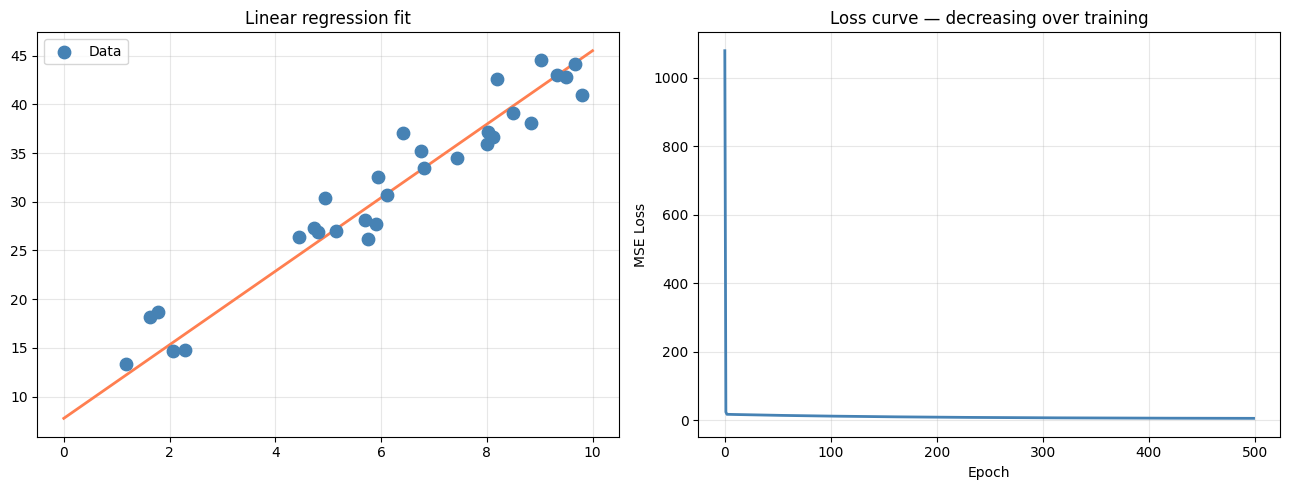

In [93]:
# CAPSTONE: implement LinearRegressionGD
#
# Your class needs:
#   __init__(self, lr=0.01, epochs=500)
#   fit(self, X, y)       — runs gradient descent, stores w, b, loss_history
#   predict(self, X)      — returns w*X + b
#   plot_loss(self)       — plots loss curve
#
# After implementing:
#   1. Fit on X_cap, y_cap
#   2. Print final w and b (should be close to 3.5 and 10)
#   3. Plot the fitted line over the data
#   4. Plot the loss curve
#   5. Compare to sklearn LinearRegression — print both w and b side by side

# YOUR CODE HERE
from sklearn.linear_model import LinearRegression

class LinearRegressionGD:
    def __init__(self, w=0, b=0, lr=0.01, epoch=500):
        self.w = w
        self.b = b
        self.lr = lr
        self.epoch = epoch
        self.loss_history = []
    
    def fit(self, X, y):
        n = len(X)
        for ep in range(self.epoch):
            y_pred = self.w * X  + self.b
            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)
            
            dw = (2 / n) * np.sum((y_pred - y) * X)
            db = (2 / n) * np.sum(y_pred - y)

            self.w = self.w - (self.lr * dw)
            self.b = self.b - (self.lr * db)
        print(f'\nLinear Regression GD: Final: w={self.w:.4f}  b={self.b:.4f}')
    
    
    def predict(self, x):
        return self.w * x + self.b

customLR = LinearRegressionGD()
skLR = LinearRegression()

customLR.fit(X_cap, y_cap)
skLR.fit(X_cap.reshape(-1, 1), y_cap)
print(f'SK Linear Regression: Final: w={skLR.coef_[0]:.4f}  b={skLR.intercept_:.4f}')


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x_line = np.linspace(0, 10, 100)
# Fitted line
axes[0].scatter(X_cap, y_cap, color='steelblue', s=80, zorder=5, label='Data')
axes[0].plot(x_line, [customLR.predict(x) for x in x_line], 'coral', lw=2)
axes[0].set_title('Linear regression fit')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss curve
axes[1].plot(customLR.loss_history, 'steelblue', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Loss curve — decreasing over training')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
